In [49]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

## PART 1: Raytracer

In [56]:
RED=np.array([1.0, 0.0, 0.0])
GREEN=np.array([0.0, 1.0, 0.0])
BLUE=np.array([0.0, 0.0, 1.0])
WHITE=np.array([1.0, 1.0, 1.0])

In [223]:
class Sphere():
    def __init__(self, center, color, r=None):
        self.c = np.asarray(center)
        self.color = np.asarray(color)
        self.r = r

    # adapted from jamesbowman/raytrace
    def intersect(self, origin, direction):
        if self.r is None:
            dist = np.linalg.norm(self.c - origin, axis=-1)
            r = dist * 0.005
        else:
            r = self.r
        
        b = 2 * np.dot(direction, (origin - self.c))
        c1 = self.c @ self.c
        c2 = origin @ origin
        c3 = self.c @ origin
        c4 = r * r
        c = c1 + c2 - 2 * c3 - c4
        disc = b * b - 4 * c
        sq = np.sqrt(np.maximum(0, disc))
        h0 = (-b - sq) / 2
        h1 = (-b + sq) / 2
        h = np.where((h0 > 0) & (h0 < h1), h0, h1)
        pred = (disc > 0) & (h > 0)
        return np.where(pred, h, np.inf)

In [224]:
## Rendering
def raytrace(origin, direction, scene):
    distances = np.array([s.intersect(origin, direction) for s in scene])
    nearest = np.min(distances, axis=0)
    color = np.zeros((direction.shape[0], 3))  # R=0 G=0 B=0
    for (s, d) in zip(scene, distances):
        hit = (nearest != np.inf) & (d == nearest)
        color[hit] = s.color
    return color

def render(scene, camera, w=128, h=128, step=0.1):
    r = float(w) / h
    screen = (-1, 1 / r + .25, 1, -1 / r + .25)
    x = np.tile(np.linspace(screen[0], screen[2], w), h)
    y = np.repeat(np.linspace(screen[1], screen[3], h), w)
    q = np.hstack((x.reshape(-1, 1), y.reshape(-1, 1), np.ones((x.shape[0], 1))))

    images = np.empty((4, w, h, 3))
    c = np.copy(camera)
    for i in range(images.shape[0]):
        direction = q - c
        direction = direction / np.linalg.norm(direction, axis=1, keepdims=True)
        images[i] = raytrace(c, direction, scene).reshape(w, h, 3)
        c += np.array([0.0, 0.0, step])

    return images

def display(images):
    n_frames = images.shape[0]
    fig, axes = plt.subplots(
        1, n_frames,
        figsize=(3 * n_frames, 3.2),
        facecolor="#ffffff"
    )
    fig.subplots_adjust(wspace=0.04)
    
    if n_frames == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    plt.show()

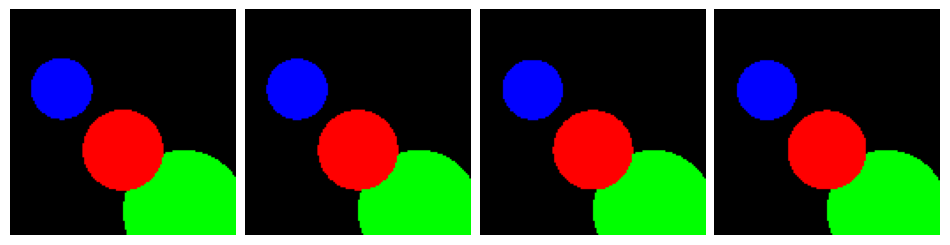

In [225]:
scene = [Sphere([0.0, 0.0, 5.0],  RED,   0.6),
         Sphere([1.0, -1.0, 6.0], GREEN, 1.0),
         Sphere([-1.0, 1.0, 6.0], BLUE, 0.5)]
camera = np.array([0.0, 0.0, -5.0])

images = render(scene, camera)
display(images)

## PART 2: Dataset

In [226]:
def dot_scene(distance, count=200, spread_xy=1.0, depth_jitter=1.0,
                   min_radius=0.01, max_radius=0.03):
    scene = []

    for _ in range(count):
        x = random.uniform(-spread_xy, spread_xy)
        y = random.uniform(-spread_xy, spread_xy)
        z = random.uniform(distance - depth_jitter, distance + depth_jitter)
        r = min_radius + (max_radius - min_radius) * (random.random() ** 2)
        scene.append(Sphere([x, y, z], WHITE, None))

    return scene

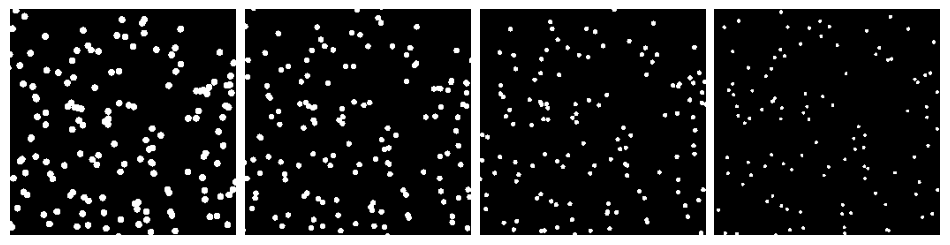

In [227]:
## Near scene
scene = dot_scene(0.0)
camera = np.array([0.0, 0.0, -5.0])

images = render(scene, camera, w=256, h=256, step=1.0)
display(images)

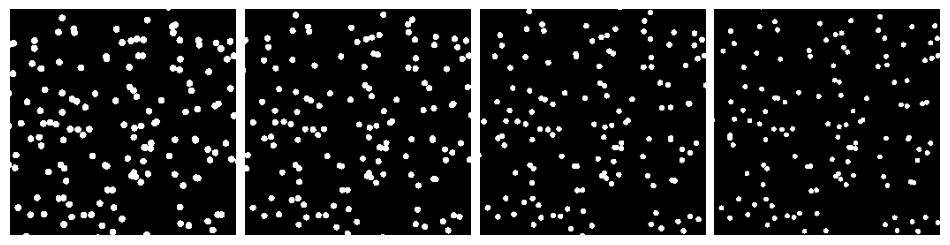

In [228]:
## Far scene
scene = dot_scene(0.0)
camera = np.array([0.0, 0.0, -5.0])

images = render(scene, camera, 256, 256, step=0.5)
display(images)